In [2]:
import numpy as np

np.seterr(divide="ignore", invalid="ignore")


def definite(prim, x1, x2, y1, y2):
    return prim(x1, y1) + prim(x2, y2) - prim(x1, y2) - prim(x2, y1)


def DiscrGF(xc, yc, zc, a, b):

    def prim1(u, v, h):
        return (u * np.arcsinh(v / np.sqrt(u**2 + h**2)) +
                v * np.arcsinh(u / np.sqrt(v**2 + h**2)) -
                h * np.arctan(u * v / (h * np.sqrt(u**2 + v**2 + h**2))))

    zc = zc + np.finfo(float).eps
    result = (prim1(xc + a/2, yc + b/2, zc) + prim1(xc - a/2, yc - b/2, zc) -
              prim1(xc + a/2, yc - b/2, zc) - prim1(xc - a/2, yc + b/2, zc))
    return result / (a * b)


def AvDiscrGF(xc, yc, zc, a, b):

    zc = zc + np.finfo(float).eps

    prim1 = lambda u, v: (u * np.arcsinh(v / np.sqrt(u**2 + zc**2)) +
                          v * np.arcsinh(u / np.sqrt(v**2 + zc**2)) -
                          zc * np.arctan(u * v / (zc * np.sqrt(u**2 + v**2 + zc**2))))
    prim2 = lambda u, v: (0.5 * (v * np.sqrt(u**2 + v**2 + zc**2)
                          + (u**2 + zc**2) * np.arcsinh(v / np.sqrt(u**2 + zc**2))))
    prim3 = lambda u, v: (0.5 * (u * np.sqrt(u**2 + v**2 + zc**2)
                          + (v**2 + zc**2) * np.arcsinh(u / np.sqrt(v**2 + zc**2))))
    prim4 = lambda u, v: (1.0/3.0 * (u**2 + v**2 + zc**2)**1.5)

    Yuu = ((xc - a)*(yc - b)*definite(prim1, xc-a, xc, yc-b, yc)
           - (yc - b)*definite(prim2, xc-a, xc, yc-b, yc)
           - (xc - a)*definite(prim3, xc-a, xc, yc-b, yc)
           + definite(prim4, xc-a, xc, yc-b, yc))
    Yud = (-(xc - a)*(yc + b)*definite(prim1, xc-a, xc, yc, yc+b)
           + (yc + b)*definite(prim2, xc-a, xc, yc, yc+b)
           + (xc - a)*definite(prim3, xc-a, xc, yc, yc+b)
           - definite(prim4, xc-a, xc, yc, yc+b))
    Ydu = (-(xc + a)*(yc - b)*definite(prim1, xc, xc+a, yc-b, yc)
           + (yc - b)*definite(prim2, xc, xc+a, yc-b, yc)
           + (xc + a)*definite(prim3, xc, xc+a, yc-b, yc)
           - definite(prim4, xc, xc+a, yc-b, yc))
    Ydd = ((xc + a)*(yc + b)*definite(prim1, xc, xc+a, yc, yc+b)
           - (yc + b)*definite(prim2, xc, xc+a, yc, yc+b)
           - (xc + a)*definite(prim3, xc, xc+a, yc, yc+b)
           + definite(prim4, xc, xc+a, yc, yc+b))
    return (Yuu + Yud + Ydu + Ydd) / (a * b)**2


In [3]:
import numpy as np


def resolver_placa_unica_ancla(N, flag_galerkin, aside=1.0, bside=1.0):
    M = N
    a, b = aside / M, bside / N
    x = np.linspace(a/2, aside - a/2, M)
    y = np.linspace(b/2, bside - b/2, N)
    xmat, ymat = np.meshgrid(x, y)
    xvec = xmat.flatten(order='F')
    yvec = ymat.flatten(order='F')
    ndim = M * N

    XC = xvec[:, np.newaxis] - xvec[np.newaxis, :]
    YC = yvec[:, np.newaxis] - yvec[np.newaxis, :]
    ZC = np.zeros_like(XC)

    mom = AvDiscrGF(XC, YC, ZC, a, b) if flag_galerkin else DiscrGF(XC, YC, ZC, a, b)
    exc = np.ones((ndim, 1))
    charge = np.linalg.solve(mom, exc)
    return float(np.sum(charge))


CNORM_PAPER = 0.3667

print("=== Conexión con el articulo: placa cuadrada aislada, Cnorm -> 0.3667 ===")
print("(unico punto de contacto numerico con un valor publicado disponible para")
print(" este proyecto")
print(f"{'N':>4} {'PM':>10} {'err PM%':>9} {'Galerkin':>10} {'err Gal%':>9}")

resultados_ancla = []
for N in [6, 20, 40]:
    cap_pm = resolver_placa_unica_ancla(N, flag_galerkin=False)
    cap_gal = resolver_placa_unica_ancla(N, flag_galerkin=True)
    err_pm = 100 * (cap_pm - CNORM_PAPER) / CNORM_PAPER
    err_gal = 100 * (cap_gal - CNORM_PAPER) / CNORM_PAPER
    print(f"{N:>4} {cap_pm:>10.4f} {err_pm:>8.2f}% {cap_gal:>10.4f} {err_gal:>8.2f}%")
    resultados_ancla.append((N, cap_pm, cap_gal))

_, _, cap_gal_40 = resultados_ancla[-1]
err_final = 100 * (cap_gal_40 - CNORM_PAPER) / CNORM_PAPER
TOL_PCT = 1.0
ok = abs(err_final) < TOL_PCT
print(f"\n[{'OK ' if ok else 'FALLO'}] Galerkin en N=40 vs. paper (Cnorm={CNORM_PAPER}): "
      f"calculado={cap_gal_40:.4f}  error={err_final:+.2f}%  (tol={TOL_PCT}%)")
if not ok:
    print("  -> ADVERTENCIA: fuera de tolerancia, revisar el kernel antes de confiar "
          "en el caso de dos placas.")

=== Conexión con el articulo: placa cuadrada aislada, Cnorm -> 0.3667 ===
(unico punto de contacto numerico con un valor publicado disponible para
 este proyecto
   N         PM   err PM%   Galerkin  err Gal%
   6     0.3477    -5.18%     0.3550    -3.20%
  20     0.3607    -1.63%     0.3629    -1.04%
  40     0.3637    -0.82%     0.3648    -0.52%

[OK ] Galerkin en N=40 vs. paper (Cnorm=0.3667): calculado=0.3648  error=-0.52%  (tol=1.0%)


In [4]:
import numpy as np


A_TOP, A_BOT, H = 1.0, 0.5, 0.3
TRESH = 10.0


def construir_placa(A, N, z):
    Delta = A / N
    coords = np.linspace(-A/2 + Delta/2, A/2 - Delta/2, N)
    xmat, ymat = np.meshgrid(coords, coords)
    xvec = xmat.flatten(order='F')
    yvec = ymat.flatten(order='F')
    zvec = np.full_like(xvec, z)
    return xvec, yvec, zvec, Delta


def resolver_dos_placas(N_bot, a_top=A_TOP, a_bot=A_BOT, h_sep=H,
                         tresh=TRESH, flag_galerkin=False, verbose=True):
    N_top = round(a_top / a_bot * N_bot)
    assert abs(N_top - a_top / a_bot * N_bot) < 1e-9, (
        "a_top/a_bot * N_bot debe ser entero -- ajustar N_bot.")

    x_top, y_top, z_top, d_top = construir_placa(a_top, N_top, +h_sep/2)
    x_bot, y_bot, z_bot, d_bot = construir_placa(a_bot, N_bot, -h_sep/2)
    Delta = d_top
    assert abs(d_top - d_bot) < 1e-12, "el tamano de celda debe ser identico en ambas placas"

    x = np.concatenate([x_top, x_bot])
    y = np.concatenate([y_top, y_bot])
    z = np.concatenate([z_top, z_bot])
    n_top_cells, n_bot_cells = N_top**2, N_bot**2
    ndim = n_top_cells + n_bot_cells

    is_top = np.zeros(ndim, dtype=bool)
    is_top[:n_top_cells] = True

    XC = x[:, np.newaxis] - x[np.newaxis, :]
    YC = y[:, np.newaxis] - y[np.newaxis, :]
    ZC = z[:, np.newaxis] - z[np.newaxis, :]
    rh = np.sqrt(XC**2 + YC**2)
    R = np.sqrt(rh**2 + ZC**2)

    gf_cerca = AvDiscrGF(XC, YC, ZC, Delta, Delta) if flag_galerkin \
        else DiscrGF(XC, YC, ZC, Delta, Delta)
    with np.errstate(divide="ignore"):
        gf_lejos = 1.0 / R
    mom = np.where(rh > tresh * Delta, gf_lejos, gf_cerca)

    def resolver(v_top, v_bot):
        exc = np.where(is_top, v_top, v_bot).reshape(-1, 1)
        charge = np.linalg.solve(mom, exc)
        return charge, np.sum(charge[is_top]), np.sum(charge[~is_top])

    charge_A, C11, C21 = resolver(1.0, 0.0)
    charge_B, C12, C22 = resolver(0.0, 1.0)

    err_recip = 100 * abs(C12 - C21) / (0.5 * abs(C12 + C21))

    if verbose:
        motor = "Galerkin" if flag_galerkin else "PM"
        asym = np.max(np.abs(mom - mom.T))
        print(f"[{motor}] N_bot={N_bot} N_top={N_top} Delta={Delta:.4f} ndim={ndim}")
        print(f"  C11={C11:.5f}  C22={C22:.5f}  C12={C12:.5f}  C21={C21:.5f}")
        print(f"  reciprocidad C12=C21: diferencia={err_recip:.4f}%  "
              f"(exacta por simetria de la matriz MoM, max|M-M^T|={asym:.2e})")

    return {
        "N_top": N_top, "N_bot": N_bot, "Delta": Delta, "ndim": ndim,
        "C11": C11, "C22": C22, "C12": C12, "C21": C21, "err_recip": err_recip,
        "x": x, "y": y, "z": z, "is_top": is_top,
        "charge_A": charge_A, "charge_B": charge_B,
        "n_top_cells": n_top_cells, "n_bot_cells": n_bot_cells,
        "a_top": a_top, "a_bot": a_bot, "h_sep": h_sep,
    }


if __name__ == "__main__":
    print("=== Solver de dos placas de tamano distinto (motor PM) ===")
    print(f"A_top={A_TOP}  A_bot={A_BOT}  h={H}\n")
    r = resolver_dos_placas(N_bot=20)

    print("\n=== Mismo caso con motor Galerkin (comparacion rapida) ===")
    r_gal = resolver_dos_placas(N_bot=20, flag_galerkin=True)

=== Solver de dos placas de tamano distinto (motor PM) ===
A_top=1.0  A_bot=0.5  h=0.3

[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47181  C22=0.24004  C12=-0.16103  C21=-0.16103
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)

=== Mismo caso con motor Galerkin (comparacion rapida) ===
[Galerkin] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47402  C22=0.24194  C12=-0.16248  C21=-0.16248
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=1.49e-10)


In [5]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


a = b = 1.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))


xc = np.linspace(0.001, 2.0, 400)
psi_a = AvDiscrGF(xc, 0.0, 0.0, a, b)
gamma_a = DiscrGF(xc, 0.0, 0.0, a, b)
g_a = 1.0 / xc

ax1.plot(xc, psi_a, "-", color="steelblue", linewidth=2, label=r"$\Psi$ (Galerkin, AvDiscrGF)")
ax1.plot(xc, gamma_a, "--", color="crimson", linewidth=2, label=r"$\Gamma$ (PM, DiscrGF)")
ax1.plot(xc, g_a, ":", color="black", linewidth=1.5, label=r"$G$ (plana, $1/R$)")
ax1.set_xlabel(r"$x_c$ = distancia horizontal entre centros")
ax1.set_ylabel("Valor normalizado de la GF")
ax1.set_title("(a) Celdas coplanares (mismo plano, $z_c=0$)")
ax1.set_ylim(0, 4)
ax1.legend()
ax1.grid(alpha=0.3)

zc = np.linspace(0.001, 2.0, 400)
psi_b = AvDiscrGF(0.0, 0.0, zc, a, b)
gamma_b = DiscrGF(0.0, 0.0, zc, a, b)
g_b = 1.0 / zc

ax2.plot(zc, psi_b, "-", color="steelblue", linewidth=2, label=r"$\Psi$ (Galerkin, AvDiscrGF)")
ax2.plot(zc, gamma_b, "--", color="crimson", linewidth=2, label=r"$\Gamma$ (PM, DiscrGF)")
ax2.plot(zc, g_b, ":", color="black", linewidth=1.5, label=r"$G$ (plana, $1/R$)")
ax2.set_xlabel(r"$z_c$ = distancia vertical entre centros (separacion entre placas)")
ax2.set_ylabel("Valor normalizado de la GF")
ax2.set_title("(b) Celdas apiladas/paralelas ($x_c=y_c=0$) — base del acoplamiento entre placas")
ax2.set_ylim(0, 4)
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle("Kernel MOM: celdas cuadradas unitarias, Point-Matching vs. Galerkin vs. plana (Fig. 3 eq.)")
plt.tight_layout()
plt.savefig("fig3_kernel_apiladas.png", dpi=150)
print("Guardada: fig3_kernel_apiladas.png")

print(f"\nChequeo self-terms en el limite xc,zc->0: "
      f"Gamma(0)={DiscrGF(0,0,0,a,b):.4f} (esperado 3.5255)  "
      f"Psi(0)={AvDiscrGF(0,0,0,a,b):.4f} (esperado 2.9732)")


Guardada: fig3_kernel_apiladas.png

Chequeo self-terms en el limite xc,zc->0: Gamma(0)=3.5255 (esperado 3.5255)  Psi(0)=2.9732 (esperado 2.9732)


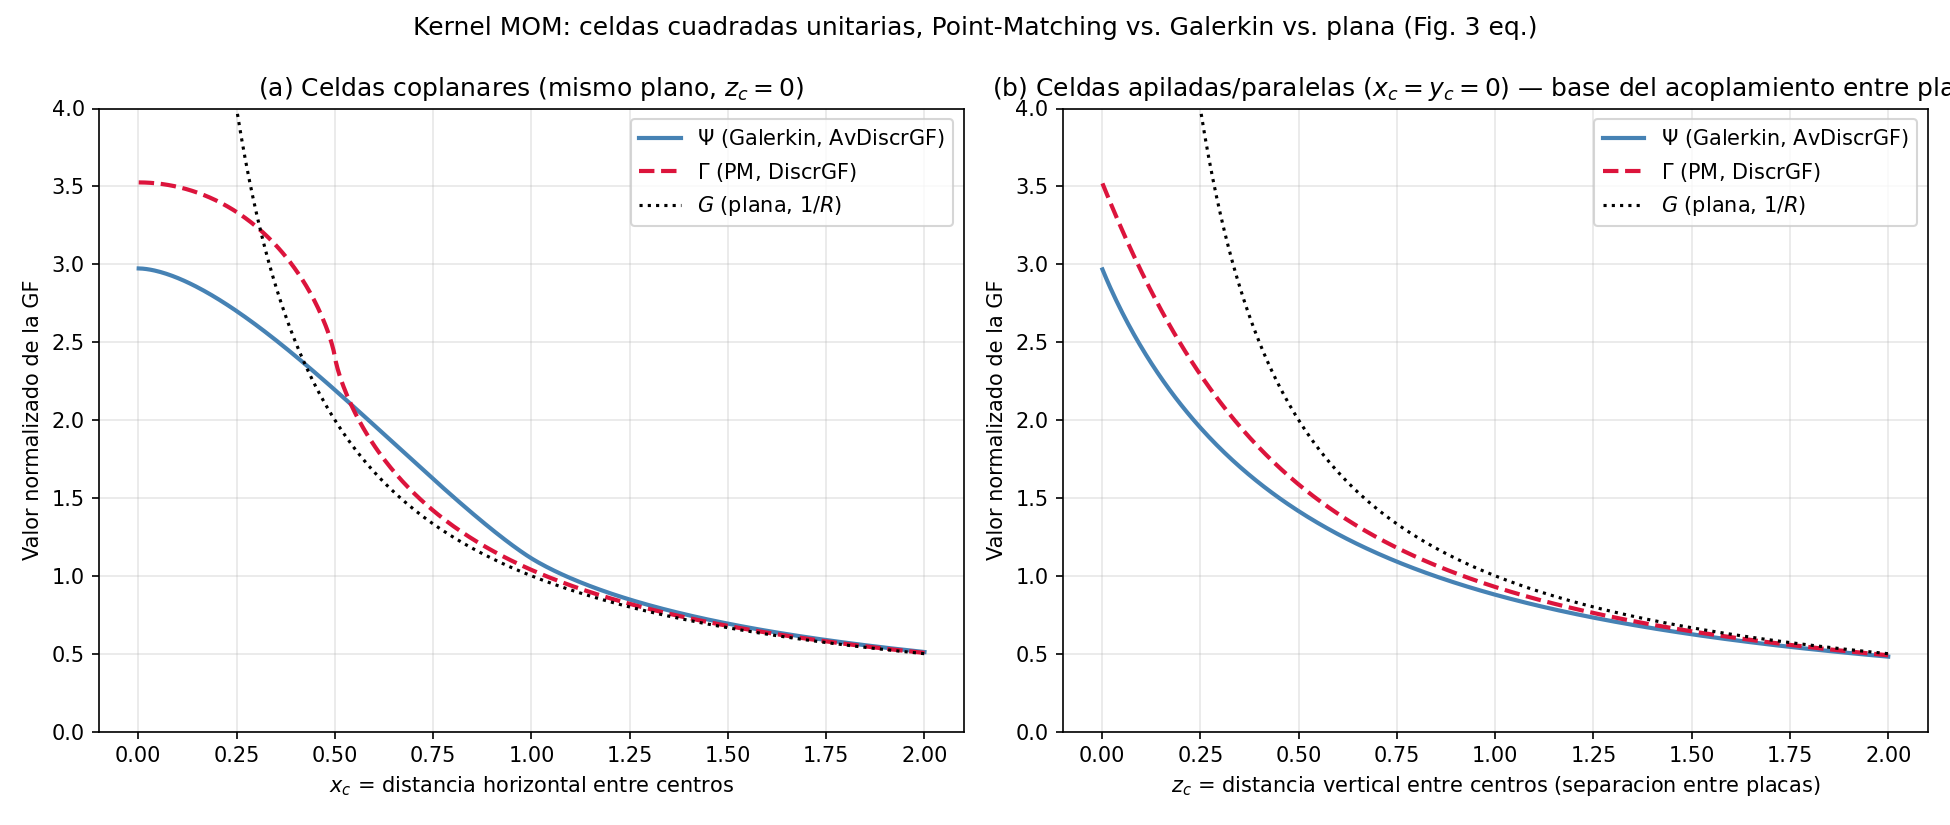

In [6]:
from IPython.display import Image
Image('fig3_kernel_apiladas.png')

In [34]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


N_BOT_PM = [10, 15, 20, 30, 40]
N_BOT_GALERKIN = [10, 15, 20, 30, 40]


def fit_p_fijo(delta_arr, C_arr, p_fijo):
    def modelo(d, Ci, a):
        return Ci + a * d ** p_fijo
    popt, _ = curve_fit(modelo, delta_arr, C_arr, p0=[C_arr[-1], C_arr[0]-C_arr[-1]], maxfev=20000)
    return popt[0], popt[1]


if __name__ == "__main__":
    print("=== Barrido PM ===")
    res_pm = [resolver_dos_placas(N, flag_galerkin=False) for N in N_BOT_PM]
    print("\n=== Barrido Galerkin ===")
    res_gal = [resolver_dos_placas(N, flag_galerkin=True) for N in N_BOT_GALERKIN]

    delta_pm = np.array([r["Delta"] for r in res_pm])
    C11_pm = np.array([r["C11"] for r in res_pm])
    C22_pm = np.array([r["C22"] for r in res_pm])
    C12_pm = np.abs(np.array([r["C12"] for r in res_pm]))

    delta_gal = np.array([r["Delta"] for r in res_gal])
    C11_gal = np.array([r["C11"] for r in res_gal])
    C22_gal = np.array([r["C22"] for r in res_gal])
    C12_gal = np.abs(np.array([r["C12"] for r in res_gal]))

    print("\n" + "=" * 78)
    print("Extrapolacion, C(Delta) = C_inf + alpha*Delta^p (p fijo en 1.0 y 0.5):")
    extrap_pm, extrap_gal = {}, {}
    for nombre, Cpm, Cgal in [("C11", C11_pm, C11_gal), ("C22", C22_pm, C22_gal),
                               ("|C12|", C12_pm, C12_gal)]:
        Ci1_pm, a1_pm = fit_p_fijo(delta_pm, Cpm, 1.0)
        Ci05_pm, a05_pm = fit_p_fijo(delta_pm, Cpm, 0.5)
        Ci1_gal, a1_gal = fit_p_fijo(delta_gal, Cgal, 1.0)
        Ci05_gal, a05_gal = fit_p_fijo(delta_gal, Cgal, 0.5)
        extrap_pm[nombre] = (Ci1_pm, a1_pm, Ci05_pm, a05_pm)
        extrap_gal[nombre] = (Ci1_gal, a1_gal, Ci05_gal, a05_gal)

        print(f"\n  {nombre}:")
        print(f"    PM       : p=1.0 -> C_inf={Ci1_pm:.5f}   p=0.5 -> C_inf={Ci05_pm:.5f}")
        print(f"    Galerkin : p=1.0 -> C_inf={Ci1_gal:.5f}   p=0.5 -> C_inf={Ci05_gal:.5f}")
        err_p1 = 100 * (Ci1_gal - Ci1_pm) / Ci1_pm
        err_p05 = 100 * (Ci05_gal - Ci05_pm) / Ci05_pm
        print(f"    Diferencia PM vs Galerkin -> C_inf(PM) vs C_inf(Galerkin):")
        print(f"      p=1.0: {err_p1:+.2f}%      p=0.5: {err_p05:+.2f}%")

    print("\n" + "=" * 78)


    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
    for ax, nombre, Cpm, Cgal, color in [
        (axes[0], "C11", C11_pm, C11_gal, "darkorange"),
        (axes[1], "C22", C22_pm, C22_gal, "seagreen"),
        (axes[2], "|C12|", C12_pm, C12_gal, "steelblue"),
    ]:
        ax.plot(delta_pm, Cpm, "o-", color=color, markersize=8, label="PM")
        ax.plot(delta_gal, Cgal, "s--", color=color, alpha=0.7, markersize=7, label="Galerkin")
        Ci1_pm, a1_pm, Ci05_pm, a05_pm = extrap_pm[nombre]
        Ci1_gal, a1_gal, Ci05_gal, a05_gal = extrap_gal[nombre]
        d_fit_pm = np.linspace(0, delta_pm.max()*1.1, 100)
        d_fit_gal = np.linspace(0, delta_gal.max()*1.1, 100)
        ax.plot(d_fit_pm, Ci1_pm + a1_pm*d_fit_pm**1.0, ":", color=color, alpha=0.35)
        ax.plot(d_fit_gal, Ci1_gal + a1_gal*d_fit_gal**1.0, ":", color=color, alpha=0.8)
        ax.plot(0, Ci1_pm, "*", color="black", markersize=11, label="extrap. PM (p=1)")
        ax.plot(0, Ci1_gal, "*", color=color, markersize=11, markeredgecolor="black",
                label="extrap. Galerkin (p=1)")
        err_p1 = 100 * (Ci1_gal - Ci1_pm) / Ci1_pm
        ax.set_xlabel(r"$\Delta$ = tamano de celda (placa chica)")
        ax.set_title(f"{nombre}  PM={Ci1_pm:.4f}  Gal={Ci1_gal:.4f}  dif={err_p1:+.2f}%",
                     fontsize=9.5)
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.3)

    fig.suptitle(f"MOM: convergencia de la capacitancia, PM vs. Galerkin (Fig. 4 eq.) — "
                 f"A_top={A_TOP}, A_bot={A_BOT}, h={H}")
    plt.tight_layout()
    plt.savefig("fig4_convergencia_mom.png", dpi=150)
    print("\nGuardada: fig4_convergencia_mom.png")

=== Barrido PM ===
[PM] N_bot=10 N_top=20 Delta=0.0500 ndim=500
  C11=0.46610  C22=0.23518  C12=-0.15737  C21=-0.15737
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=1.44e-13)
[PM] N_bot=15 N_top=30 Delta=0.0333 ndim=1125
  C11=0.46988  C22=0.23839  C12=-0.15978  C21=-0.15978
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)
[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47181  C22=0.24004  C12=-0.16103  C21=-0.16103
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)
[PM] N_bot=30 N_top=60 Delta=0.0167 ndim=4500
  C11=0.47378  C22=0.24173  C12=-0.16231  C21=-0.16231
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.25e-13)
[PM] N_bot=40 N_top=80 Delta=0.0125 ndim=8000
  C11=0.47477  C22=0.24258  C12=-0.16295  C21=-0.16295
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simet

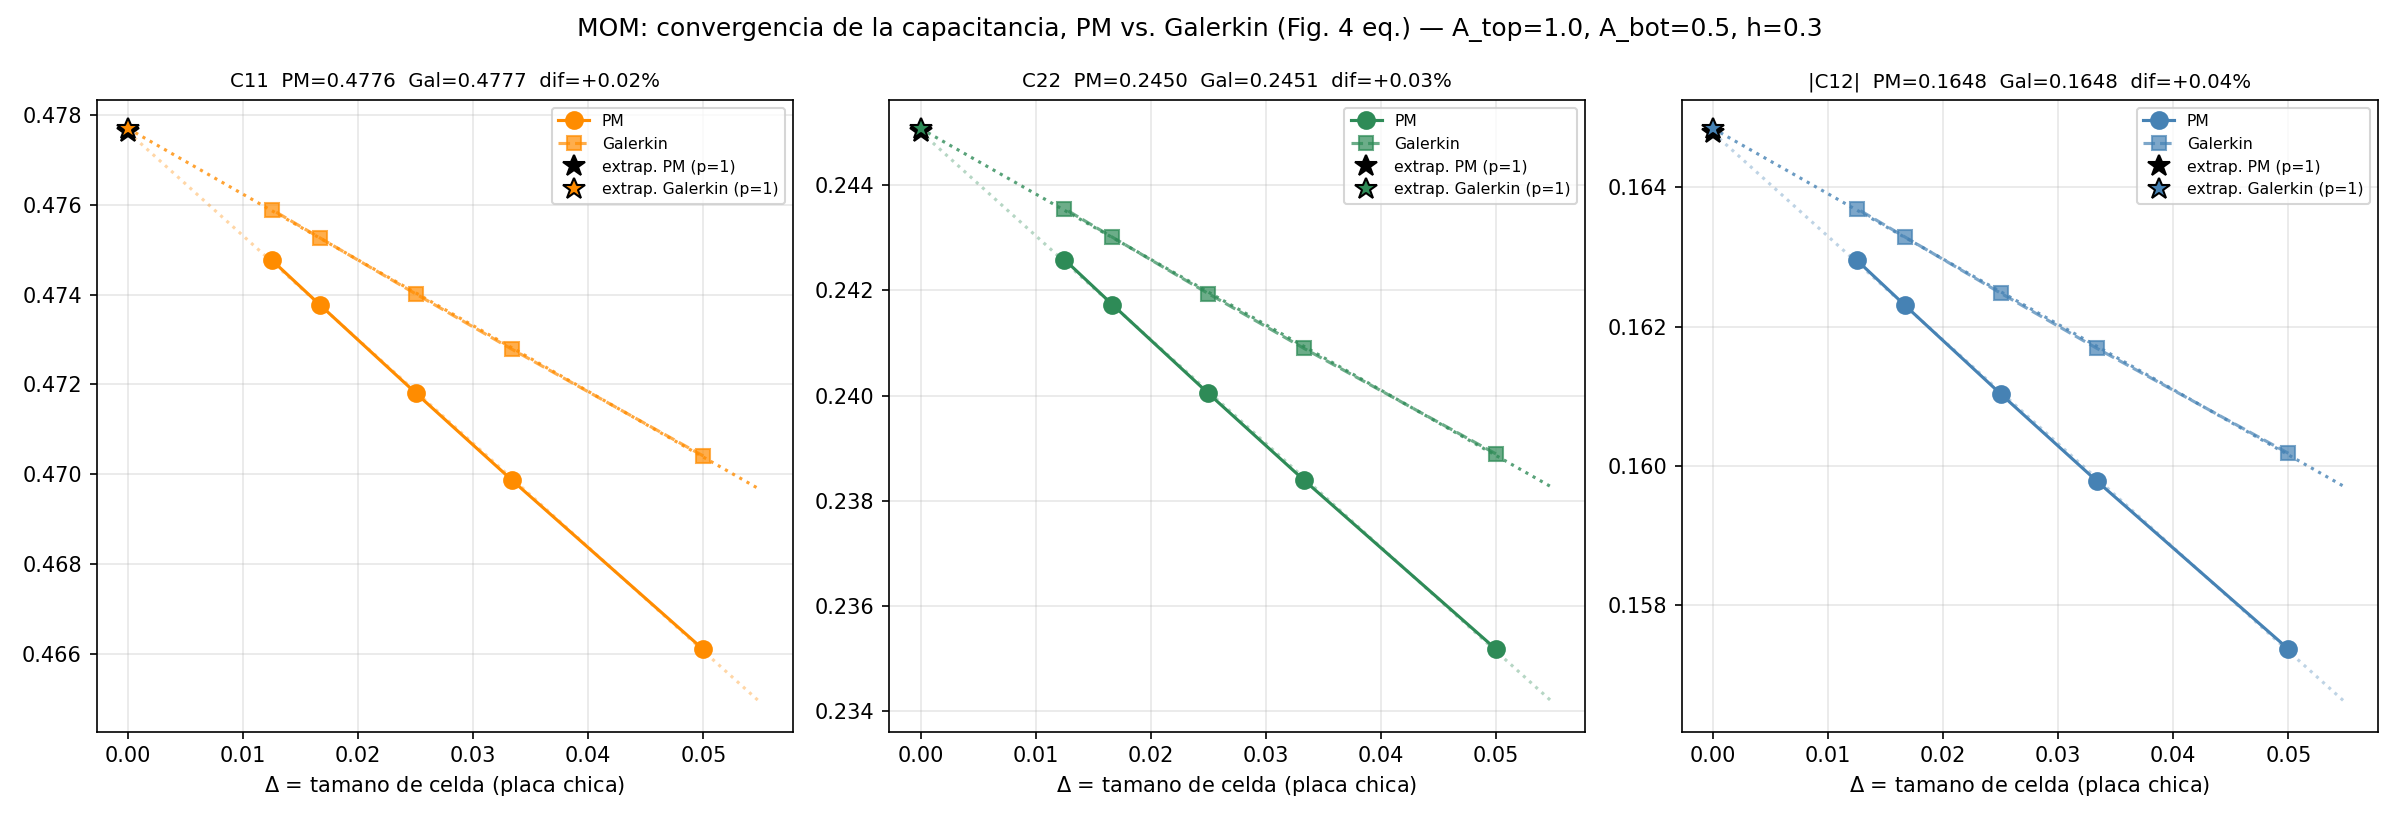

In [36]:
from IPython.display import Image
Image('fig4_convergencia_mom.png')

In [7]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


N_BOT = 20
H_VALUES = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

if __name__ == "__main__":
    resultados = []
    for h in H_VALUES:
        r = resolver_dos_placas(N_bot=N_BOT, h_sep=h, flag_galerkin=False)
        k = abs(r["C12"]) / np.sqrt(r["C11"] * r["C22"])
        print(f"  k = {k:.4f}")
        resultados.append((h, r["C11"], r["C22"], abs(r["C12"]), k))

    H_arr = np.array([r[0] for r in resultados])
    C11_arr = np.array([r[1] for r in resultados])
    C22_arr = np.array([r[2] for r in resultados])
    C12_arr = np.array([r[3] for r in resultados])
    k_arr = np.array([r[4] for r in resultados])

    print("\n" + "=" * 60)
    print(f"{'h/A_top':>8} {'C11':>10} {'C22':>10} {'|C12|':>10} {'k':>8}")
    for h, c11, c22, c12, k in resultados:
        print(f"{h:>8.2f} {c11:>10.5f} {c22:>10.5f} {c12:>10.5f} {k:>8.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

    ax1.plot(H_arr, C11_arr, "o-", color="darkorange", markersize=8, linewidth=2,
             label=r"$C_{11}$ (self, top, A=%.1f)" % A_TOP)
    ax1.plot(H_arr, C22_arr, "s-", color="seagreen", markersize=8, linewidth=2,
             label=r"$C_{22}$ (self, bottom, A=%.1f)" % A_BOT)
    ax1.plot(H_arr, C12_arr, "^-", color="steelblue", markersize=8, linewidth=2,
             label=r"$|C_{12}|=|C_{21}|$ (mutua)")
    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xlabel(r"$h/A_{top}$"); ax1.set_ylabel(r"$C_{norm}$")
    ax1.set_title("Matriz de capacitancia vs. separacion (MOM)")
    ax1.legend(); ax1.grid(alpha=0.3, which="both")

    ax2.plot(H_arr, k_arr, "D-", color="crimson", markersize=8, linewidth=2)
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$h/A_{top}$")
    ax2.set_ylabel(r"$k = |C_{12}|/\sqrt{C_{11}C_{22}}$")
    ax2.set_title("Coeficiente de acoplamiento (0=desacopladas, 1=maximo)")
    ax2.set_ylim(0, 1)
    ax2.grid(alpha=0.3, which="both")

    fig.suptitle(f"MOM: placas apiladas de distinto tamano, A_top={A_TOP}, "
                 f"A_bot={A_BOT} (Fig. 5 eq., N_bot={N_BOT})")
    plt.tight_layout()
    plt.savefig("fig5_separacion_mom.png", dpi=150)
    print("\nGuardada: fig5_separacion_mom.png")

    print(
        "\nSanity check: al aumentar h, |C12| debe -> 0 (placas desacopladas) "
        "y C11 debe acercarse a la capacitancia de la placa top aislada."
    )


[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.89208  C22=0.59968  C12=-0.56289  C21=-0.56289
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=4.00e-13)
  k = 0.7696
[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.66291  C22=0.38789  C12=-0.34065  C21=-0.34065
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=3.55e-13)
  k = 0.6718
[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.52691  C22=0.27767  C12=-0.21283  C21=-0.21283
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.89e-13)
  k = 0.5564
[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.42170  C22=0.21033  C12=-0.11039  C21=-0.11039
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=1.22e-13)
  k = 0.3707
[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.38371  C22=0.19034  C12=-0.06168  C21=-0.06168
  reciprocidad C12=C21: dif

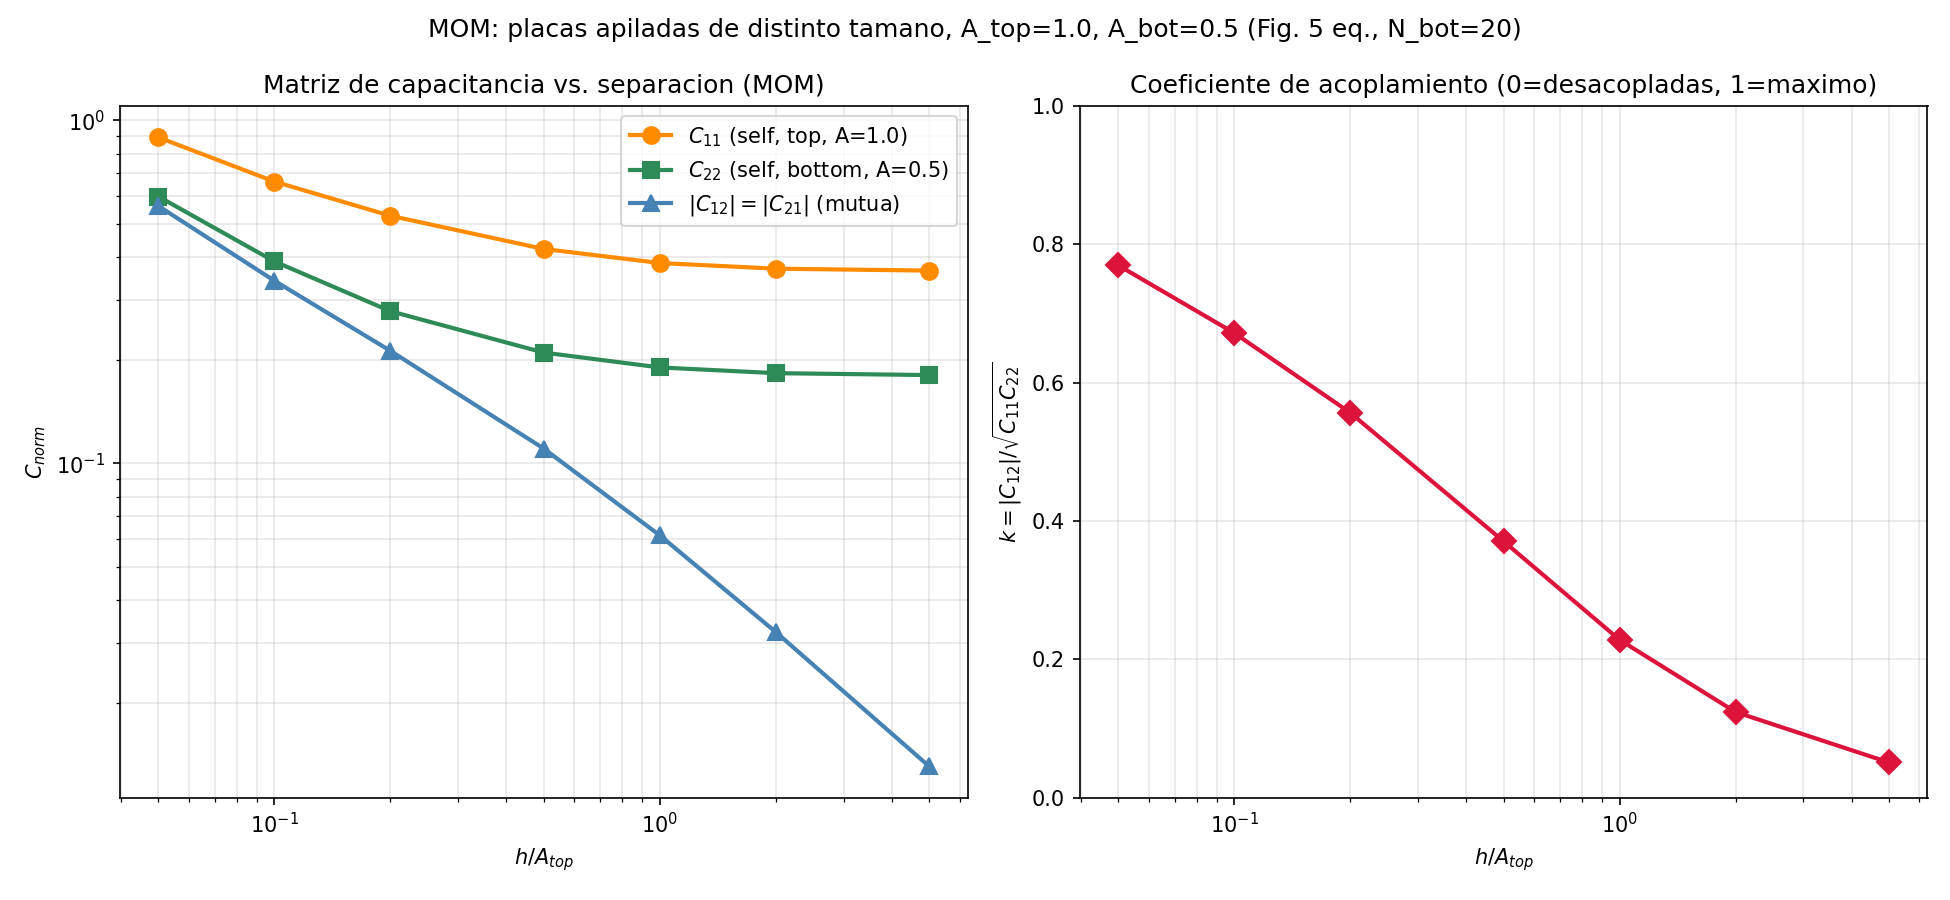

In [8]:
from IPython.display import Image
Image('fig5_separacion_mom.png')

In [9]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt



N_BOT = 20

if __name__ == "__main__":
    r = resolver_dos_placas(N_bot=N_BOT, flag_galerkin=False)
    x_src, y_src, z_src = r["x"], r["y"], r["z"]
    q = r["charge_A"].flatten()
    Delta = r["Delta"]


    NX, NZ = 260, 200
    x_eval = np.linspace(-1.5, 1.5, NX)
    z_eval = np.linspace(-1.0, 1.0, NZ)
    XX, ZZ = np.meshgrid(x_eval, z_eval)
    xe = XX.ravel()
    ze = ZZ.ravel()
    ye = np.zeros_like(xe)

    n_eval = xe.size
    V = np.zeros(n_eval)
    BLOCK = 2000
    for i0 in range(0, n_eval, BLOCK):
        i1 = min(i0 + BLOCK, n_eval)
        dx = xe[i0:i1, None] - x_src[None, :]
        dy = ye[i0:i1, None] - y_src[None, :]
        dz = ze[i0:i1, None] - z_src[None, :]
        rh = np.sqrt(dx**2 + dy**2)
        R = np.sqrt(rh**2 + dz**2)
        with np.errstate(divide="ignore"):
            gf_lejos = 1.0 / R
        gf_cerca = DiscrGF(dx, dy, dz, Delta, Delta)
        gf = np.where(rh > TRESH * Delta, gf_lejos, gf_cerca)
        V[i0:i1] = gf @ q

    V_grid = V.reshape(NZ, NX)

    fig, ax = plt.subplots(figsize=(9, 6))
    cs = ax.contourf(XX, ZZ, np.clip(V_grid, 0, 1), levels=np.linspace(0, 1, 30),
                      cmap="RdYlBu_r", vmin=0, vmax=1)
    ct = ax.contour(XX, ZZ, V_grid, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                     colors="k", linewidths=0.9)
    ax.clabel(ct, fmt="%.1f", fontsize=7)
    plt.colorbar(cs, ax=ax, label="V (normalizado, recortado en [0,1])")

    ax.plot([-A_TOP/2, A_TOP/2], [H/2, H/2], "k-", linewidth=5, label=f"Placa top (V=1), A={A_TOP}")
    ax.plot([-A_BOT/2, A_BOT/2], [-H/2, -H/2], "b-", linewidth=5, label=f"Placa bottom (V=0), A={A_BOT}")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.0, 1.0)
    ax.set_xlabel("x"); ax.set_ylabel("z")
    ax.set_title("MOM: equipotenciales en plano y=0, placas apiladas de distinto tamano\n"
                 f"A_top={A_TOP}, A_bot={A_BOT}, h={H} (escenario A, N_bot={N_BOT})")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig("fig6_equipotenciales_mom.png", dpi=150)
    print("Guardada: fig6_equipotenciales_mom.png")


[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47181  C22=0.24004  C12=-0.16103  C21=-0.16103
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)
Guardada: fig6_equipotenciales_mom.png


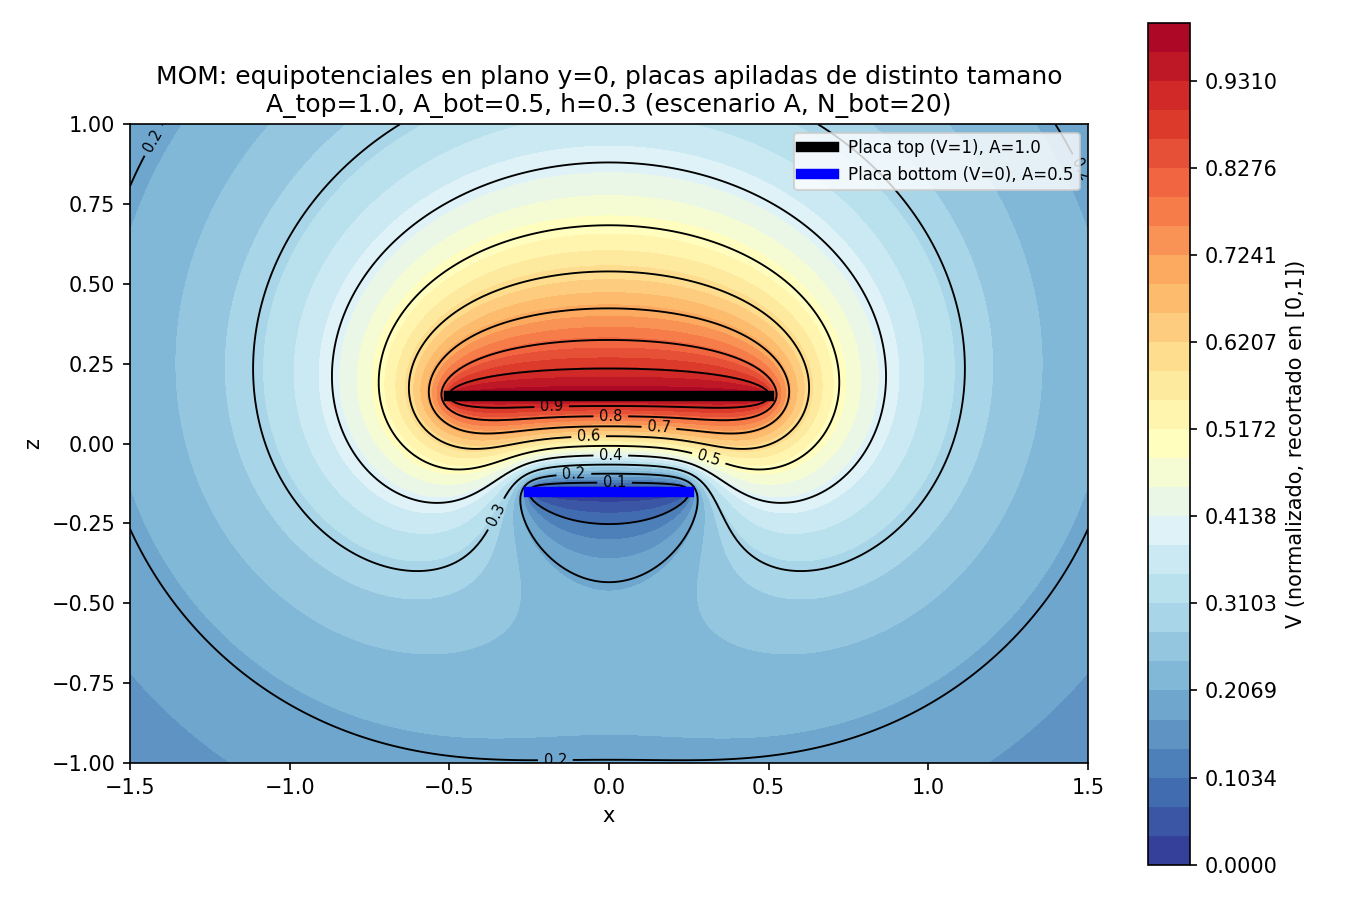

In [10]:
from IPython.display import Image
Image('fig6_equipotenciales_mom.png')

In [11]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


N_BOT = 20

if __name__ == "__main__":
    r = resolver_dos_placas(N_bot=N_BOT, flag_galerkin=False)
    Delta = r["Delta"]
    n_top, n_bot = r["n_top_cells"], r["n_bot_cells"]
    N_top, N_bot_ = r["N_top"], r["N_bot"]

    q = r["charge_A"].flatten()
    q_top = q[:n_top]
    q_bot = q[n_top:]
    x_top, y_top = r["x"][:n_top], r["y"][:n_top]
    x_bot, y_bot = r["x"][n_top:], r["y"][n_top:]

    sigma_top = (q_top / Delta**2).reshape((N_top, N_top), order='F')
    sigma_bot = (q_bot / Delta**2).reshape((N_bot_, N_bot_), order='F')
    xmat_top = x_top.reshape((N_top, N_top), order='F')
    ymat_top = y_top.reshape((N_top, N_top), order='F')
    xmat_bot = x_bot.reshape((N_bot_, N_bot_), order='F')
    ymat_bot = y_bot.reshape((N_bot_, N_bot_), order='F')

    Q_top_total = np.sum(q_top)
    Q_bot_total = np.sum(q_bot)
    print(f"Carga total placa top:    {Q_top_total:.5f}  (=C11)")
    print(f"Carga total placa bottom: {Q_bot_total:.5f}  (=C21, inducida)")

    fig = plt.figure(figsize=(13, 6))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(xmat_top, ymat_top, sigma_top, cmap="viridis", edgecolor="none")
    ax1.set_title(f"(a) Placa top (V=1, A={A_TOP})\nQ={Q_top_total:.4f}", pad=15)
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax1.set_zlabel(r"$\sigma_{norm}$", labelpad=10)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(xmat_bot, ymat_bot, np.abs(sigma_bot), cmap="viridis", edgecolor="none")
    ax2.set_title(f"(b) Placa bottom (V=0, inducida, A={A_BOT})\n|Q|={abs(Q_bot_total):.4f}", pad=15)
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    ax2.set_zlabel(r"$|\sigma_{norm}|$", labelpad=10)

    fig.suptitle(f"MOM: densidad de carga superficial, placas apiladas de distinto tamano "
                 f"(A_top={A_TOP}, A_bot={A_BOT}, h={H}) — Fig. 7 eq.")
    plt.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.05, wspace=0.35)
    plt.savefig("fig7_carga_mom.png", dpi=150)
    print("Guardada: fig7_carga_mom.png")


[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47181  C22=0.24004  C12=-0.16103  C21=-0.16103
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)
Carga total placa top:    0.47181  (=C11)
Carga total placa bottom: -0.16103  (=C21, inducida)
Guardada: fig7_carga_mom.png


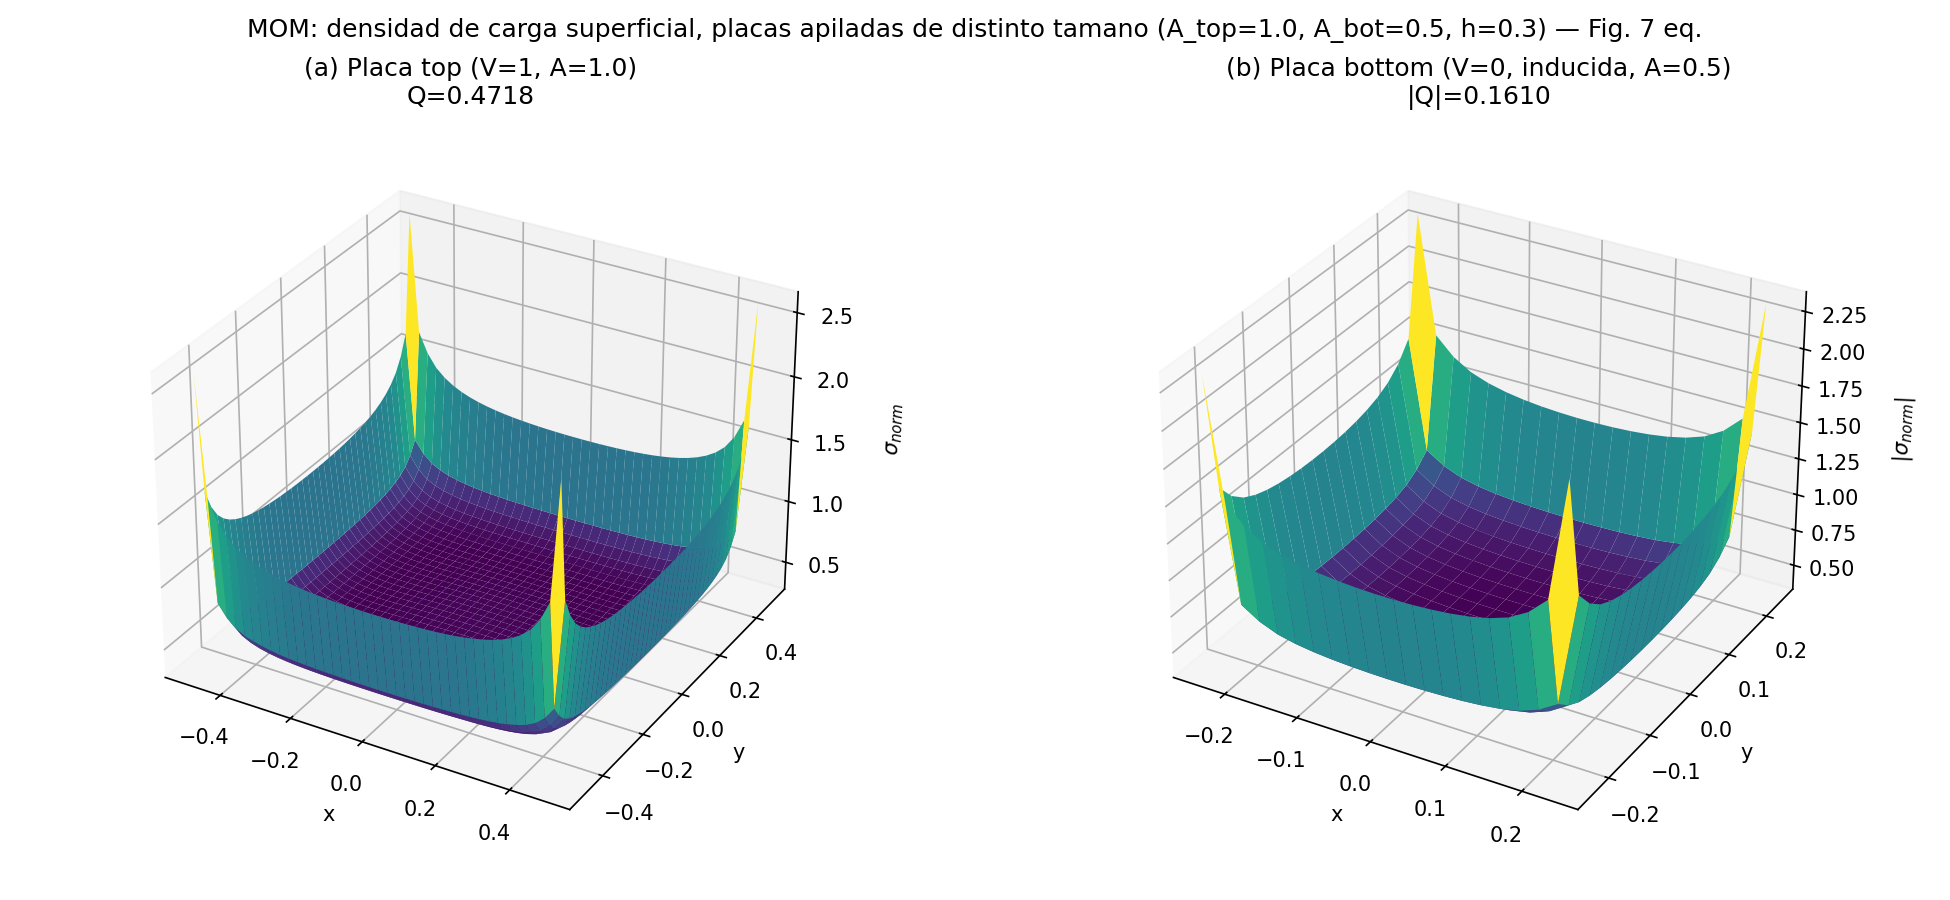

In [12]:
from IPython.display import Image
Image('fig7_carga_mom.png')

In [13]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import cm, colors

N_BOT = 20


r = resolver_dos_placas(N_bot=N_BOT, flag_galerkin=False)
D = r["Delta"]
n_top, N_top, N_bot_ = r["n_top_cells"], r["N_top"], r["N_bot"]
q = r["charge_A"].flatten()
sigma_top = np.abs(q[:n_top] / D**2).reshape((N_top, N_top), order='F')
sigma_bot = np.abs(q[n_top:] / D**2).reshape((N_bot_, N_bot_), order='F')


def hoja(ax, A, N, z, sigma, norm, cmap):
    e = np.linspace(-A/2, A/2, N + 1)
    Xe, Ye = np.meshgrid(e, e)
    Ze = np.full_like(Xe, z)
    ax.plot_surface(Xe, Ye, Ze, facecolors=cmap(norm(sigma)),
                    rstride=1, cstride=1, shade=False, linewidth=0, antialiased=False)


todos = np.concatenate([sigma_top.ravel(), sigma_bot.ravel()])
norm = colors.Normalize(vmin=todos.min(), vmax=np.percentile(todos, 97))
cmap = cm.plasma

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')
hoja(ax, A_TOP, N_top, +H/2, sigma_top, norm, cmap)
hoja(ax, A_BOT, N_bot_, -H/2, sigma_bot, norm, cmap)

for A, z in [(A_TOP, H/2), (A_BOT, -H/2)]:
    ax.plot([-A/2, A/2, A/2, -A/2, -A/2], [-A/2, -A/2, A/2, A/2, -A/2], [z]*5, "k", lw=1.2)

m = cm.ScalarMappable(norm=norm, cmap=cmap); m.set_array([])
cb = fig.colorbar(m, ax=ax, shrink=0.6, aspect=12, pad=0.1)
cb.set_label(r"$|\sigma|$ densidad de carga (norm.)")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.set_zlim(-0.6, 0.6)
ax.set_title("Densidad de carga sobre las placas apiladas\n"
             f"(color sobre la geometria real, escenario V_top=1, N_bot={N_BOT})")
ax.view_init(elev=22, azim=-60)
plt.tight_layout()
plt.savefig("fig_placas_estilo_geom.png", dpi=150, bbox_inches="tight")
print("Guardada: fig_placas_estilo_geom.png")

[PM] N_bot=20 N_top=40 Delta=0.0250 ndim=2000
  C11=0.47181  C22=0.24004  C12=-0.16103  C21=-0.16103
  reciprocidad C12=C21: diferencia=0.0000%  (exacta por simetria de la matriz MoM, max|M-M^T|=2.00e-13)
Guardada: fig_placas_estilo_geom.png


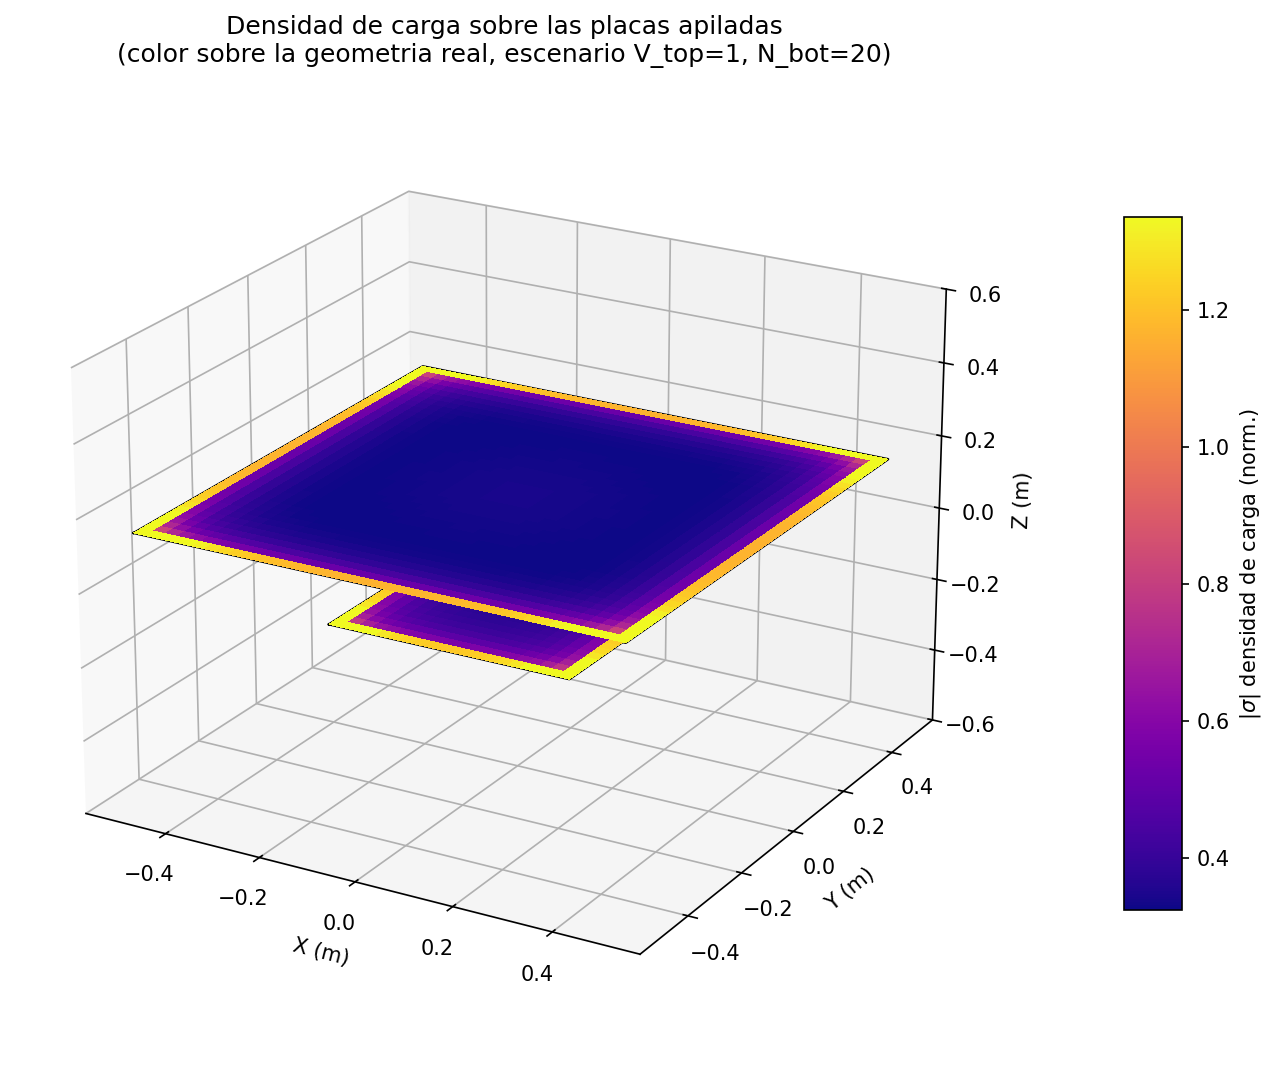

In [14]:
from IPython.display import Image
Image('fig_placas_estilo_geom.png')

In [16]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

N_BOT = 20
H_VALUES = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

res = []
for h in H_VALUES:
    r = resolver_dos_placas(N_bot=N_BOT, a_top=1.0, a_bot=1.0, h_sep=h, verbose=False)
    Ccap = 0.5 * (r["C11"] - r["C12"])
    C0 = 1.0 / (4 * np.pi * h)
    res.append((h, r["C11"], r["C12"], Ccap, Ccap / C0))

print(f"{'h/A':>6} {'C11':>9} {'|C12|':>9} {'C_cap':>9} {'C/C0':>8}")
for h, C11, C12, Ccap, fr in res:
    print(f"{h:>6.2f} {C11:>9.4f} {abs(C12):>9.4f} {Ccap:>9.4f} {fr:>8.4f}")
print(f"\n[VALIDACION] h->0: C/C0 = {res[0][4]:.4f}  (esperado -> 1.0)")

H  = np.array([r[0] for r in res])
FR = np.array([r[4] for r in res])


h_mosig   = []
ccc_mosig = []

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(H, FR, "o-", color="crimson", markersize=8, linewidth=2, label="MoM (este trabajo)")
ax.axhline(1.0, color="gray", ls="--", lw=1, label=r"límite ideal $C/C_0=1$")
if len(h_mosig) > 0 and len(h_mosig) == len(ccc_mosig):
    ax.plot(h_mosig, ccc_mosig, "ks", markersize=9, label="Mosig Fig. 5 (publicado)")
ax.set_xlabel(r"$h/A$"); ax.set_ylabel(r"$C/C_0$ (factor de fringing)")
ax.set_title("Caso puente: placas IGUALES vs. Fig. 5 de Mosig")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout()
plt.savefig("fig_puente_placas_iguales.png", dpi=150)
print("Guardada: fig_puente_placas_iguales.png")

   h/A       C11     |C12|     C_cap     C/C0
  0.02    4.2957    4.1099    4.2028   1.0563
  0.05    1.9108    1.7184    1.8146   1.1401
  0.10    1.1114    0.9104    1.0109   1.2703
  0.20    0.7087    0.4938    0.6013   1.5111
  0.50    0.4696    0.2249    0.3473   2.1819
  1.00    0.3983    0.1221    0.2602   3.2698
  2.00    0.3717    0.0637    0.2177   5.4716
  5.00    0.3626    0.0259    0.1943  12.2059

[VALIDACION] h->0: C/C0 = 1.0563  (esperado -> 1.0)
Guardada: fig_puente_placas_iguales.png


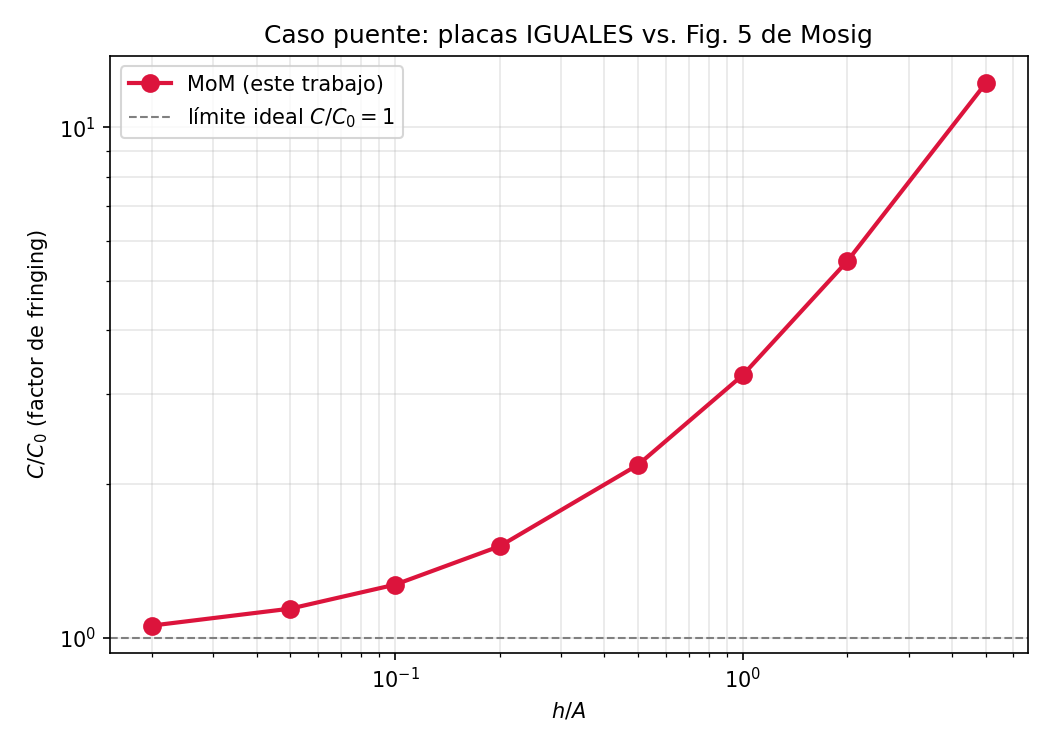

In [17]:
from IPython.display import Image
Image('fig_puente_placas_iguales.png')